In [2]:

import os
import re
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(pd.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


In [205]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()




print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [102]:
# tar -xzvf korean-english-park.train.tar.gz

In [271]:
dataset_dir = os.path.join(os.getenv("HOME"), 'work/s2s_translation/datasets') 
ko_dataset_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_dataset_path = os.path.join(dataset_dir, "korean-english-park.train.en")

with open(ko_dataset_path, "r") as f:
    ko_raw = f.read().splitlines()

print("KO Data Size:", len(ko_raw))

print("KO Example:")
for sen in ko_raw[0:100][::20]: print(">>", sen)

with open(en_dataset_path, "r") as f:
    en_raw = f.read().splitlines()

print("EN Data Size:", len(en_raw))

print("EN Example:")
for sen in en_raw[0:100][::20]: print(">>", sen)

KO Data Size: 94123
KO Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.
EN Data Size: 94123
EN Example:
>> Much of personal computing is about "can you top this?"
>> Amid mounting pressure on North Korea to abandon its nuclear weapons program Japanese and North Korean diplomats have resumed talks on normalizing diplomatic relations.
>> “Guard robots are used privately and professionally to detect intruders or fire,” Karlsson said.
>> Authorities from the Water Resources Ministry plan to begin construction next year on the controversial and hugely expensive project.
>> Researchers also have debated whether weight-training has a big impact on the heart, since it does

In [272]:
df =pd.DataFrame({"ko": ko_raw,
                 "en": en_raw
                 })

## Step 2. 데이터 정제

In [273]:
df.drop_duplicates(subset="ko", inplace=True, ignore_index=True)
df = df.replace('', pd.NA)
df = df.dropna(how = 'any')

In [274]:
df

,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...
...,...,...
77586,“우리는 3월 8일 김승연 회장과 그의 아들이 보복폭행에 가담한 혐의를 찾기 위해 ...,””We are hoping to seize material evidence to ...
77587,월요일 술집 종업원 6명은 김회장과 아들에게 폭행을 당했음을 진술했다고 경찰은 말했다.,"” On Monday, police secured statements from si..."
77588,그러나 불충분한 증거 확보로 수사에 어려움이 있다.,But the lack of material evidence is making it...
77589,김회장과 그의 아들은 보복폭행 혐의를 강력히 부인하고 있다.,Kim and his son both deny the allegations.


In [275]:
# Mecab 설치
# !pip install konlpy
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
# %cd Mecab-ko-for-Google-Colab/
# !bash install_mecab-ko_on_colab_light_220429.sh

In [276]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [277]:
def preprocess_sentence(sentence, is_ko):
    
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    if is_ko:
        sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)
        
    else:
        sentence = sentence.lower().strip()
        sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
        sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

In [278]:
df["ko"] = df["ko"].apply(lambda x: preprocess_sentence(x, is_ko=True))
df["en"] = df["en"].apply(lambda x: preprocess_sentence(x, is_ko=False))

df.head()

,ko,en
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also does not n..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


In [16]:
df = df.replace('', pd.NA)
df = df.dropna(how = 'any')
df

,ko,en
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also does not n..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...
...,...,...
77586,우리는 월 일 김승연 회장과 그의 아들이 보복폭행에 가담한 혐의를 찾기 위해 총력을...,we are hoping to seize material evidence to pr...
77587,월요일 술집 종업원 명은 김회장과 아들에게 폭행을 당했음을 진술했다고 경찰은 말했다 .,"on monday , police secured statements from six..."
77588,그러나 불충분한 증거 확보로 수사에 어려움이 있다 .,but the lack of material evidence is making it...
77589,김회장과 그의 아들은 보복폭행 혐의를 강력히 부인하고 있다 .,kim and his son both deny the allegations .


공백 및 mecba을 통한 토큰화
토큰 길이 제한을 통한 filtering
eos, sos token
토큰화 정의하여 special token 정의 (unk, eos, sos, pad)
vocab size 10000 조정
정수 인코딩 및 패딩


## 토큰화

In [279]:
# Mecab 설치
#!pip install konlpy
#!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
#%cd Mecab-ko-for-Google-Colab/
#!bash install_mecab-ko_on_colab_light_220429.sh

In [280]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


In [281]:
from collections import Counter

class Tokenizer:
    def __init__(self, vocab_size=10000, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters
        self.vocab_size = vocab_size


    def fit_on_texts(self, corpus):
        tokens_list = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            temp_list = []
            for token in tokens:
                if token not in self.filters: # 불용어 처리
                    temp_list.append(token)
            tokens_list.append(temp_list)   
        
        words = np.concatenate(tokens_list).tolist()    
        counter = Counter(words)
        counter = counter.most_common(self.vocab_size-4)
        vocab = ['<PAD>', '<BOS>', '<EOS>', '<UNK>'] + [key for key, _ in counter]

        self.word_index = {word:index for index, word in enumerate(vocab)}
     
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus, is_decoder=False):
        sequences = []
        input_sequences = []
        target_sequences = []

        if is_decoder:
            for sentence in corpus:
                tokens = sentence.split() if isinstance(sentence, str) else sentence
                seq = [self.word_index.get(token, 3) for token in tokens] # vocab에 없는 token은 3로 (<UNK>) 정수 인코딩
            
                input_seq = [self.word_index.get('<BOS>')] + seq
                target_seq = seq + [self.word_index.get('<EOS>')]
                
                input_sequences.append(torch.tensor(input_seq, dtype=torch.long))
                target_sequences.append(torch.tensor(target_seq, dtype=torch.long))
            return [input_sequences, target_sequences]
            
        else:
            for sentence in corpus:
                tokens = sentence.split() if isinstance(sentence, str) else sentence
                seq = [self.word_index.get(token, 3) for token in tokens] # vocab에 없는 token은 3로 (<UNK>) 정수 인코딩
                sequences.append(torch.tensor(seq, dtype=torch.long))
            return sequences


    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

In [282]:
import torch 
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence


def tokenize(corpus, vocab_size=10000, is_decoder=False):
    tokenizer = Tokenizer(vocab_size)
    tokenizer.fit_on_texts(corpus)
    int_sequences = tokenizer.texts_to_sequences(corpus, is_decoder)
    
    return int_sequences, tokenizer

In [283]:
from konlpy.tag import Mecab

mecab = Mecab()

def mecab_split(sentence):
    return mecab.morphs(sentence)


ko_corpus = []
for kor in df['ko']:    
    ko_corpus.append(mecab_split(kor)) # 토큰화

en_corpus = []
for en in df['en']:    
    en_corpus.append(en.split()) # 토큰화

ko_tensor, ko_tokenizer = tokenize(ko_corpus, vocab_size=20000, is_decoder=False)
en_tensor, en_tokenizer = tokenize(en_corpus, vocab_size=20000, is_decoder=True)

df['encoder_input'] = ko_tensor
df['decoder_input'] = en_tensor[0]
df['decoder_target'] = en_tensor[1]

# 토큰 max length 40
# 추가적으로 legnth가 1인 case를 살펴 봤을 때, '.' 만 존재하는 다수 존재함으로 2 이상인 sequence로 filtering
df = df[(df['encoder_input'].apply(lambda x: len(x) <= 40)) &
    (df['encoder_input'].apply(lambda x: len(x) > 1))]

df = df[df['decoder_input'].apply(lambda x: len(x) <= (40+1)) & 
    (df['decoder_input'].apply(lambda x: len(x) > 1))]

df.reset_index(drop=True, inplace=True)

encoder_input_train = pad_sequence(df['encoder_input'], batch_first=True, padding_value=0)
decoder_input_train = pad_sequence(df['decoder_input'], batch_first=True, padding_value=0)
decoder_target_train = pad_sequence(df['decoder_target'], batch_first=True, padding_value=0)

print('encoder input shape: ', encoder_input_train.shape)
print('decoder input shape: ', decoder_input_train.shape)
print('decoder target shape: ', decoder_target_train.shape)


encoder input shape:  torch.Size([62954, 40])
decoder input shape:  torch.Size([62954, 41])
decoder target shape:  torch.Size([62954, 41])


## 모델 설계

In [288]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [289]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [290]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [291]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40, bos_id = 2, eos_id=3):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [293]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(ko_tokenizer.word_index)
output_dim = len(en_tokenizer.word_index)
emb_dim = 256
hid_dim = 512

encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

## 모델 훈련

In [294]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 256

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0) # pad_id = 0

train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)




In [295]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 246/246 [03:35<00:00,  1.14it/s, loss=5.27]


Epoch 1/20, Train Loss: 5.7683


Epoch 2: 100%|██████████| 246/246 [03:35<00:00,  1.14it/s, loss=4.4] 


Epoch 2/20, Train Loss: 4.6716


Epoch 3: 100%|██████████| 246/246 [03:35<00:00,  1.14it/s, loss=4.02]


...

Epoch 18/20, Train Loss: 0.7837


Epoch 19: 100%|██████████| 246/246 [03:35<00:00,  1.14it/s, loss=0.752]


Epoch 19/20, Train Loss: 0.7195


Epoch 20: 100%|██████████| 246/246 [03:35<00:00,  1.14it/s, loss=0.788]

Epoch 20/20, Train Loss: 0.6640
CPU times: user 53min 23s, sys: 18min 31s, total: 1h 11min 55s
Wall time: 1h 11min 52s


## 모델 저장

In [296]:
save_dir = os.path.join(os.getenv('HOME') + '/work/s2s_translation/models/')
torch.save(model, save_dir + "s2s_baseline_vocab20000_model.pth")

## 모델 불러오기

In [303]:
save_dir = os.path.join(os.getenv('HOME') + '/work/s2s_translation/models/')
base_model = torch.load(save_dir + "s2s_baseline_model.pth", weights_only=False, map_location=device)
v20000_model = torch.load(save_dir + "s2s_baseline_vocab20000_model.pth", weights_only=False, map_location=device)

## 모델 평가

In [270]:
#!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]


In [297]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_sentence(sentence,  is_ko=True)
    sentence = mecab_split(sentence)
    
    src_ids = encoder_tokenizer.texts_to_sequences(sentence, is_decoder=False)
    src_ids = src_ids[:max_len]

    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    #src_ids = src_ids + [torch.tensor([0])] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = decoder_tokenizer.sequences_to_texts([outputs.argmax(2).squeeze(1)])
    result = result[0]

    if "<EOS>" in result:
        result = result[:result.index("<EOS>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [298]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontproperties=fontprop, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [299]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)
    sentence = " ".join(sentence)
    result = " ".join(result)
    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result.split()), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result.split())

### Vocab size: 10000

Input: 오바마 는 대통령 이 다 .
Predicted translation: obama is the first thing to president .


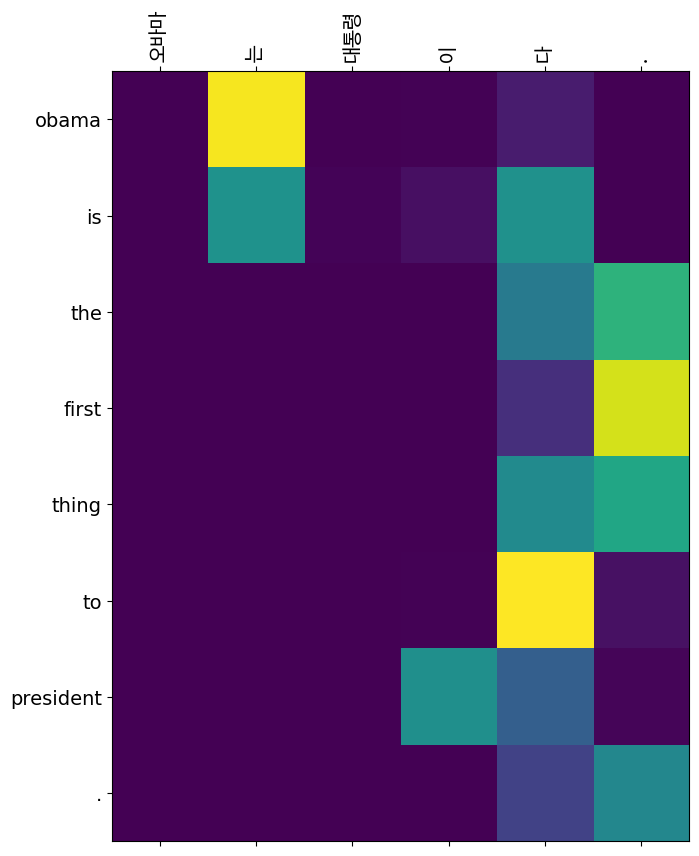

In [304]:
# 실행 예제
translate("오바마는 대통령이다.", base_model, ko_tokenizer, en_tokenizer, max_len=40)

Input: 시민 들 은 도시 속 에 산다 .
Predicted translation: <UNK>


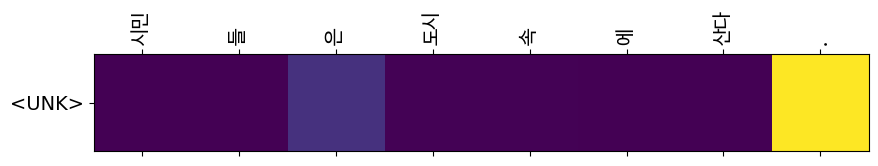

In [305]:
translate("시민들은 도시 속에 산다.", base_model, ko_tokenizer, en_tokenizer, max_len=40)

Input: 커피 는 필요 없 다 .
Predicted translation: coffee is non not necessary for the coffee is a small no . for the <UNK>


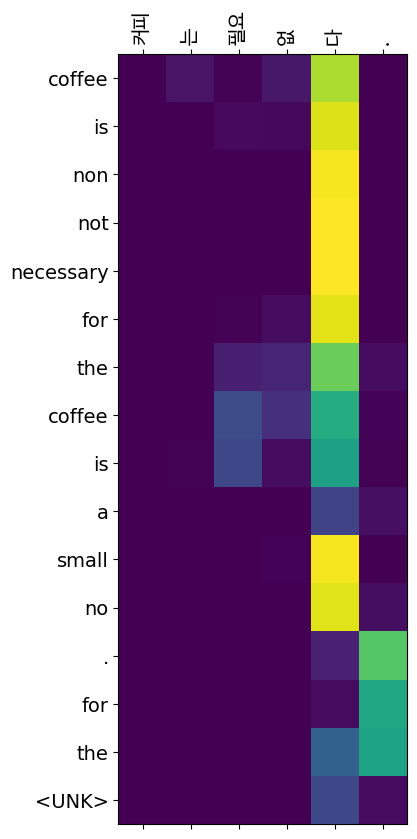

In [306]:
translate("커피는 필요 없다.", base_model, ko_tokenizer, en_tokenizer, max_len=40)

Input: 일곱 명 의 사망자 가 발생 했 다 .
Predicted translation: seven year killed people were killed .


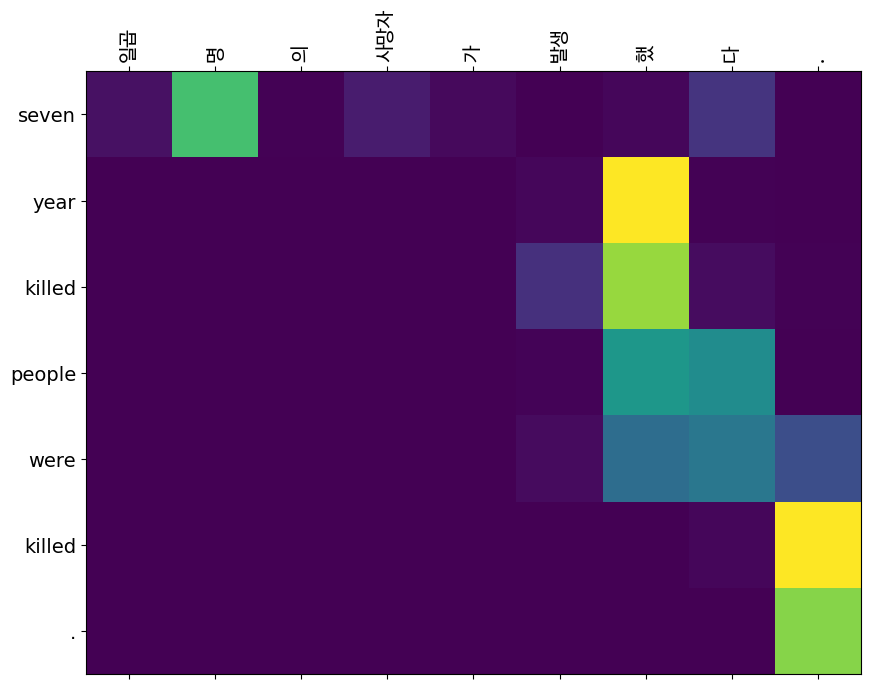

In [307]:
translate("일곱 명의 사망자가 발생했다.", model, ko_tokenizer, en_tokenizer, max_len=40)

### Vocab size: 20000

Input: 오바마 는 대통령 이 다 .
Predicted translation: obama is the president .


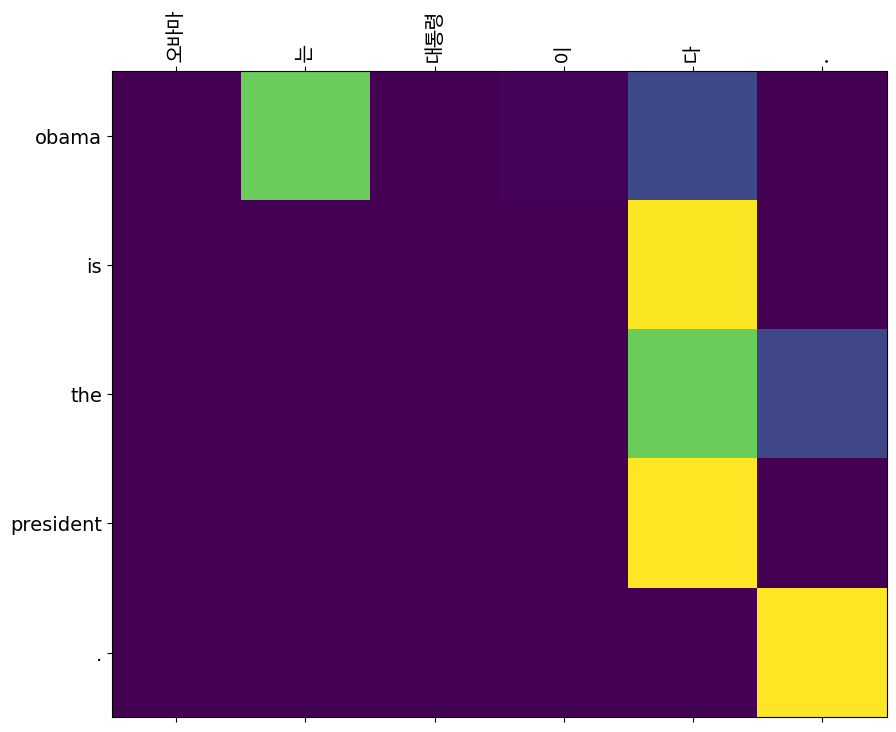

In [308]:
translate("오바마는 대통령이다.", v20000_model, ko_tokenizer, en_tokenizer, max_len=40)

Input: 시민 들 은 도시 속 에 산다 .
Predicted translation: interior <UNK>


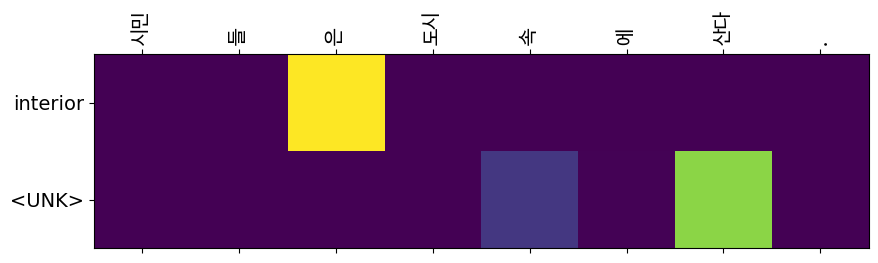

In [309]:
translate("시민들은 도시 속에 산다.", v20000_model, ko_tokenizer, en_tokenizer, max_len=40)

Input: 커피 는 필요 없 다 .
Predicted translation: coffee measures by coffee


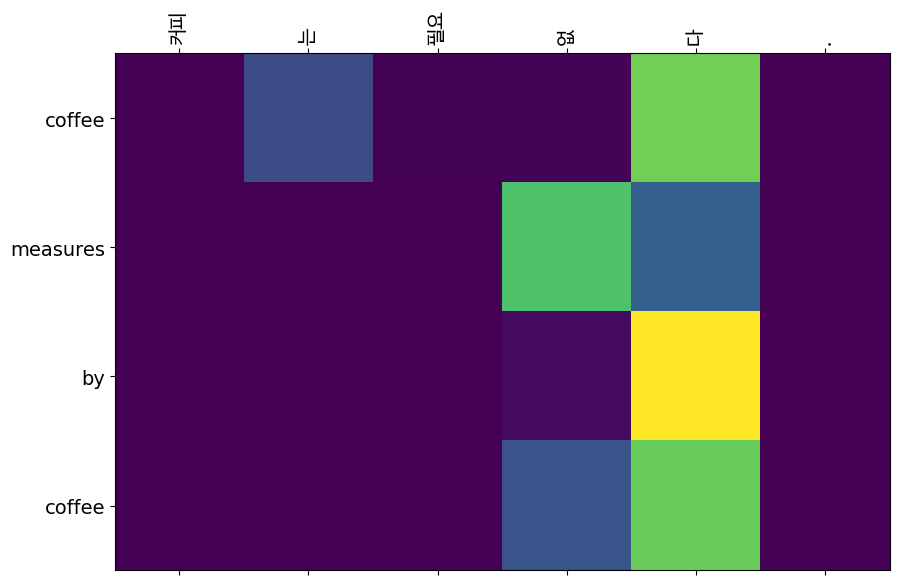

In [310]:
translate("커피는 필요 없다.", v20000_model, ko_tokenizer, en_tokenizer, max_len=40)

Input: 일곱 명 의 사망자 가 발생 했 다 .
Predicted translation: seven year killed people were killed .


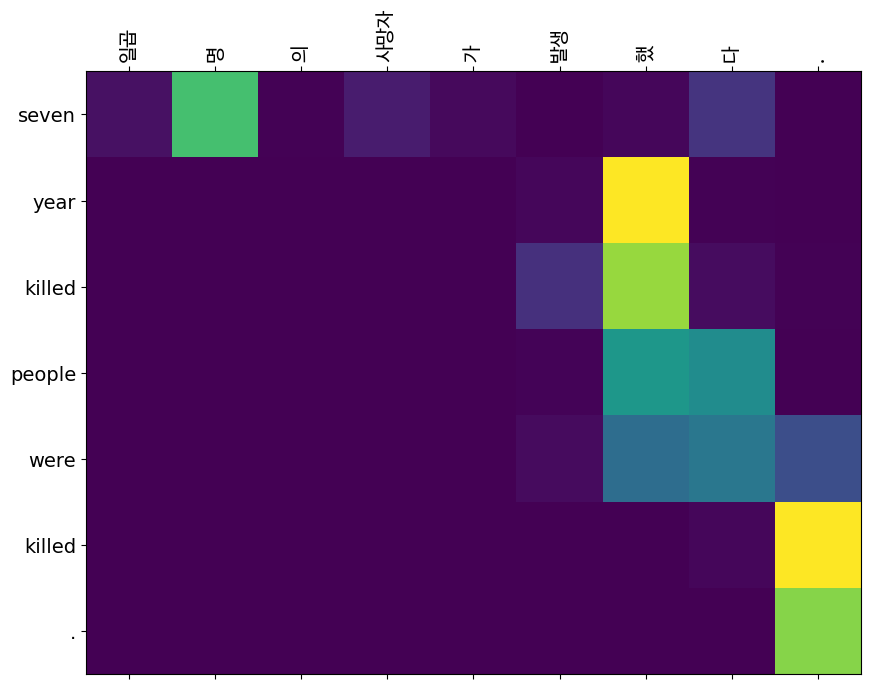

In [311]:
translate("일곱 명의 사망자가 발생했다.", v20000_model, ko_tokenizer, en_tokenizer, max_len=40)

vocab의 크기를 키우더라도 성능 변화가 거의 없음을 확인할 수 있었다.

### 평가 metric에 대한 고찰
#### 정량적 평가 
- 기계 번역에서 평가 metric으로 활용할 수 있는 지표는 크게 통계적 방법과 딥러닝 방법으로 나눌 수 있다. 통계적 방법에 대표적인 방법으로는 BLEU score가 있으먀, 딥러닝 방법으로는 BertScore가 있다.
- 통계적 방법은 주로 예측 token과 정답 token 간의 n-gram을 기반으로 완벽히 '일치' 하는 가를 기준으로 평가한다. 그러나, 언어라는 것은 의미가 동일하지만 다양하게 표현될 수 있기에, 정확히 정답과 동일하게 예측할 필요없이 의미와 문맥이 유사하도록 번역하기만 하면 된다.
- 이러한 점에서 통계적 방식이 한계점을 갖으나 BertScore는 사전학습된 Bert 모델을 통해  sequence의 의미적 유사성을 반영하여 번역 performance를 정량화 할 수 있다.
- Bert모델로 정답과 예측 sequence의 의미가 담긴 embedding vector를 추출할 수 있고, 이들 간의 cosine similirity를 계산하여 점수를 산출할 수 있다.

#### 정성적 평가
- 정성적 평가 방식으로 번역의 performance를 판단할 수 있는 합리적인 guidelines을 정의하고, 해당 기준을 기반으로 점수화 할 수 있다.
- 이후, 각 기준에 대한 점수를 평균하여 정성적 평가로 활용할 수 있을 것이다.
- 이를 테면, 아래와 같이 guidelines을 선정해 볼 수 있다.
  
    1. 원문의 의미가 얼마나 정확하게 보존되었는가
    2. 문법적으로 자연스러운가
    3. 문체가 유사한가